In [378]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [379]:
#load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [380]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [381]:
#one hot encode objects
cat_cols = train.select_dtypes(include=["object", "category"]).columns
train_encoded = pd.get_dummies(train, columns=cat_cols, drop_first=True)


In [382]:
train.isna().sum().to_frame(name="missing_values")

#these could affect the heatmap in the future, but lets see what it spits out considering these might be irrelevant with the columns description 
# or little to no na's to begin with

,missing_values
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


C:\Users\bulle\AppData\Local\Temp\ipykernel_505140\2403956273.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = train.corr()


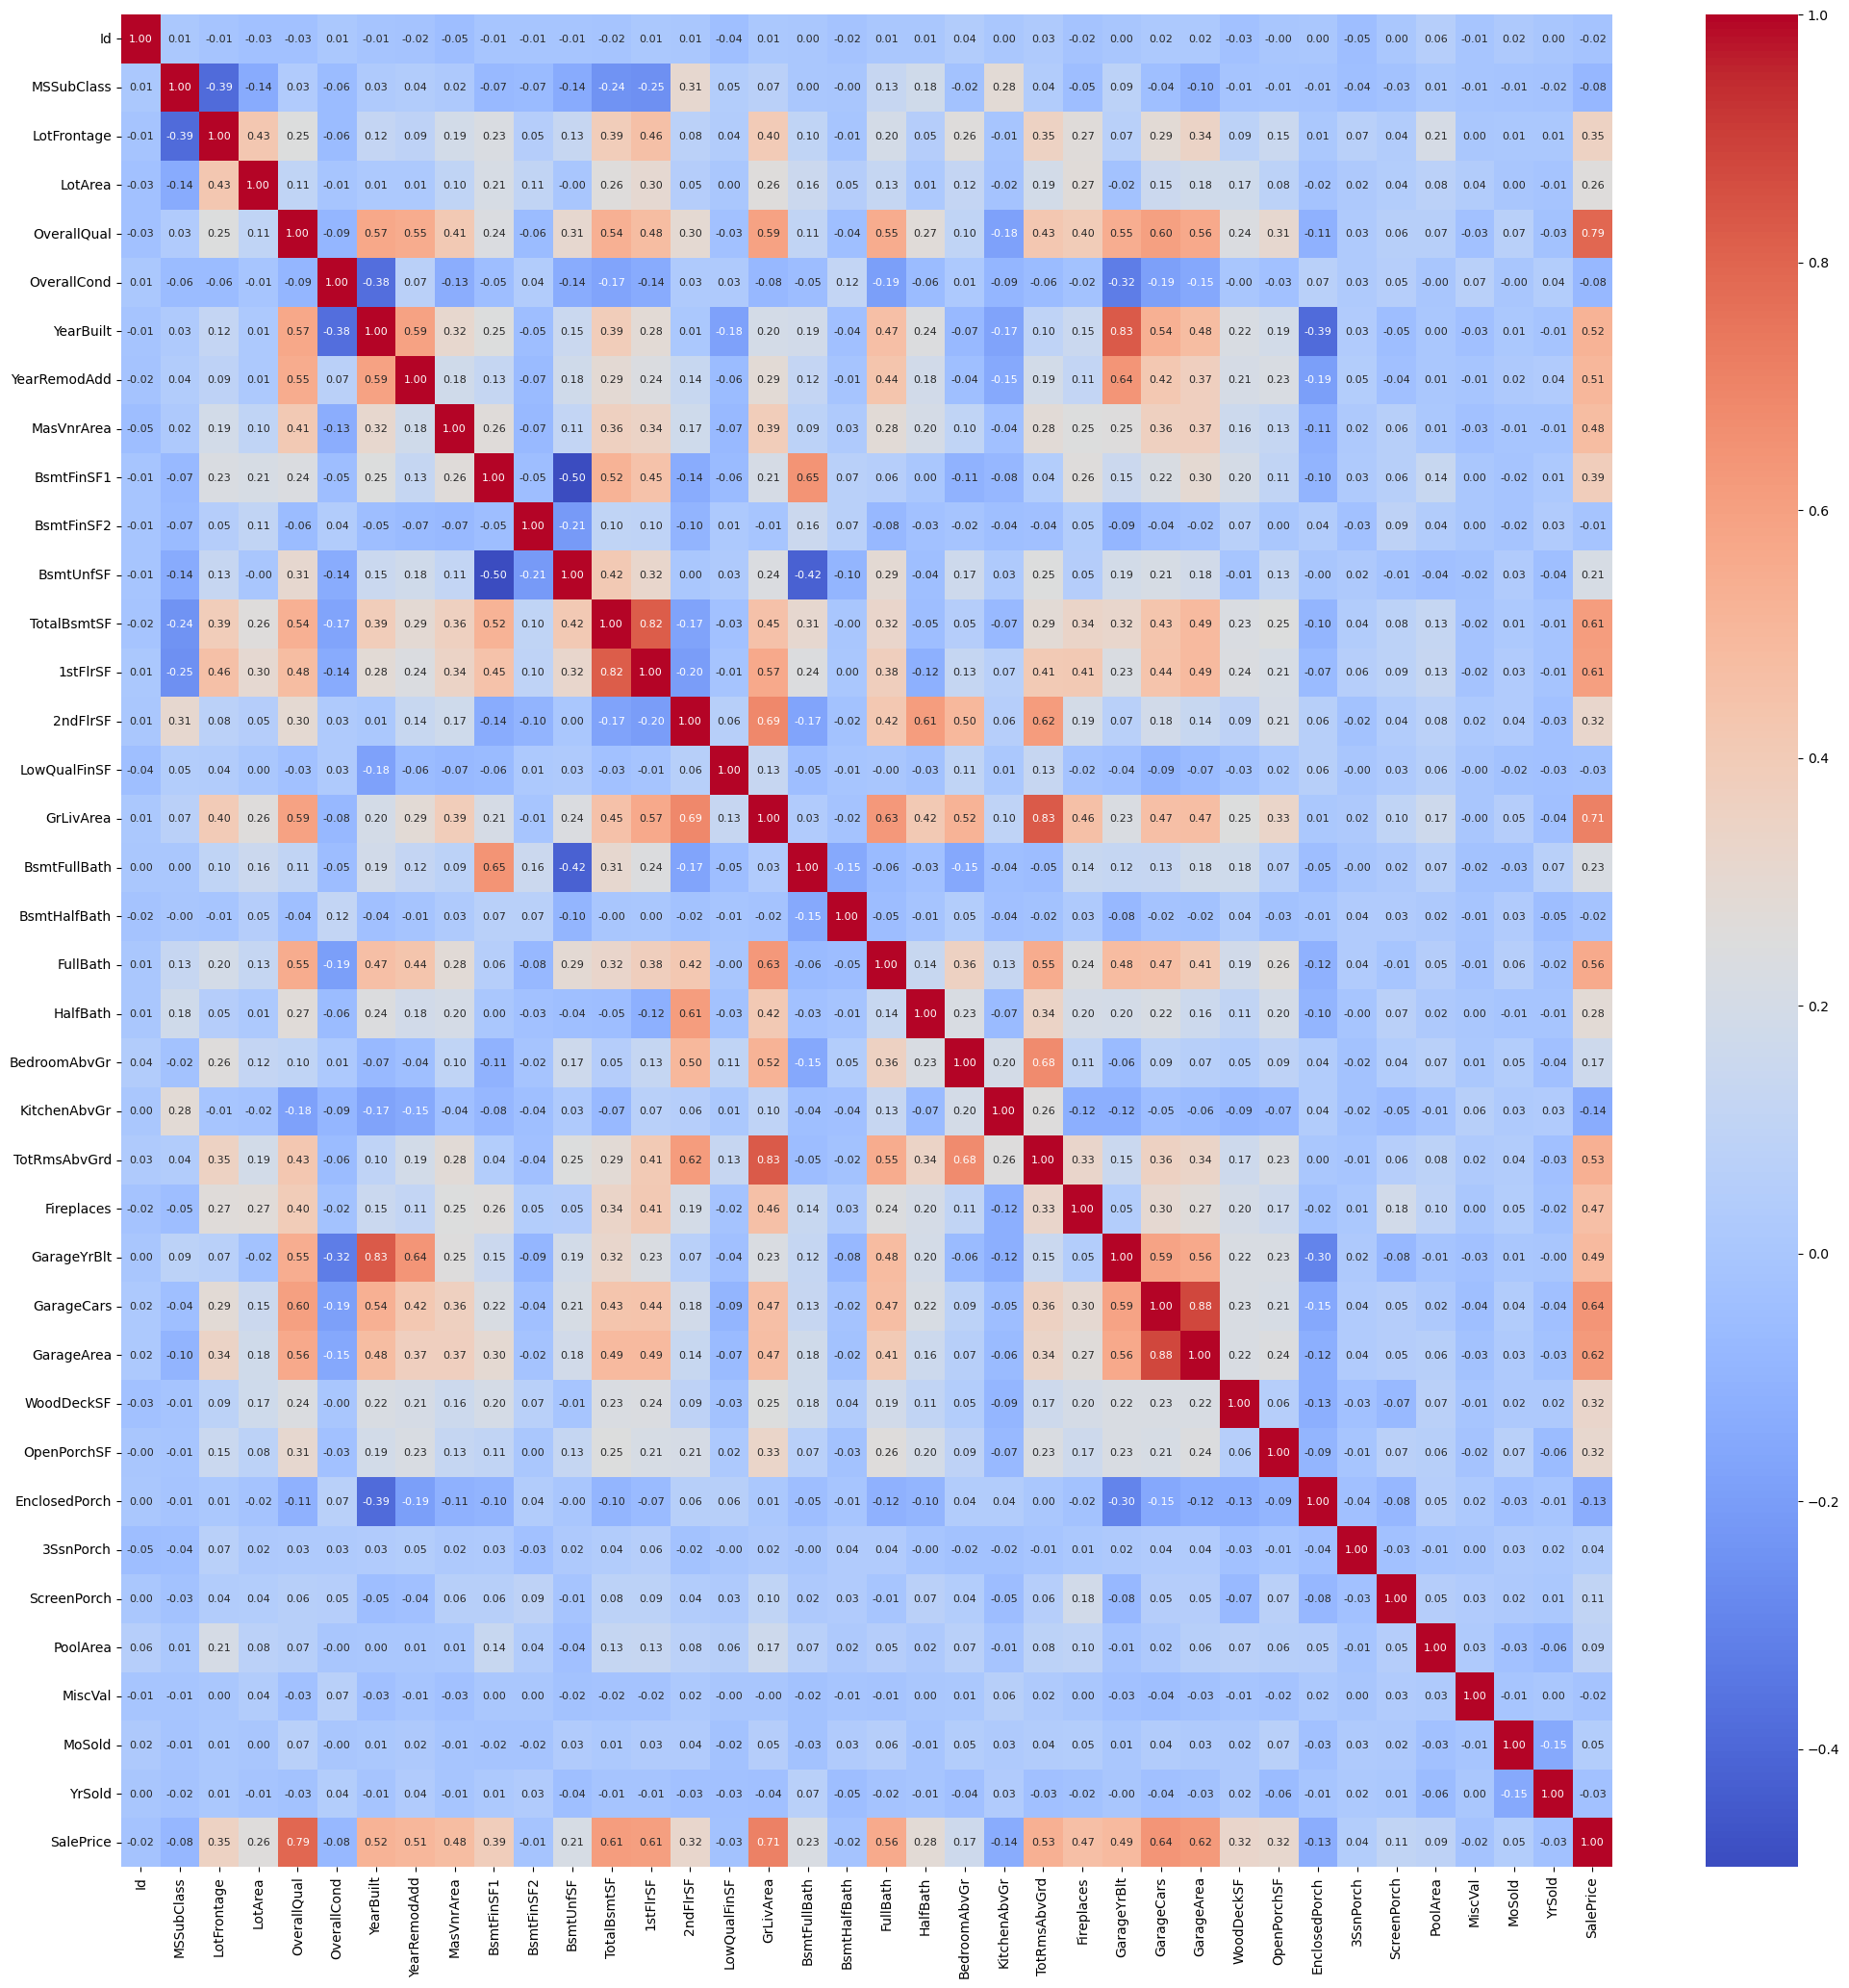

In [383]:
#make heatmap to see correlations
import seaborn as sns
plt.figure(figsize=(25,25))
correlation_matrix = train.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":8})
plt.show()

In [384]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

OverallQual     1845.443859
totalArea       1264.753177
GrLivArea       1031.133326
YearBuilt        805.581901
GarageCars       762.912782
GarageArea       654.505097
FullBath         635.054695
TotalBsmtSF      557.440386
YearRemodAdd     552.632119
1stFlrSF         446.691515
Fireplaces       273.728269
TotRmsAbvGrd     264.980014
LotFrontage       98.582986
dtype: float64

In [385]:

# Select features with absolute correlation > 0.3 with SalePrice
corr_with_sale = correlation_matrix['SalePrice'].abs()
selected_features = corr_with_sale[corr_with_sale > 0.3].index.tolist()
# Ensure SalePrice is included
if 'SalePrice' not in selected_features:
    selected_features.append('SalePrice')

housing_price = train[selected_features].copy()
print("Selected features (|corr| > 0.3):", selected_features)
print("housing_price shape:", housing_price.shape)
housing_price.head()

Selected features (|corr| > 0.3): ['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'SalePrice']
housing_price shape: (1460, 19)


,LotFrontage,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,SalePrice
0,65.0,7,2003,2003,196.0,706,856,856,854,1710,2,8,0,2003.0,2,548,0,61,208500
1,80.0,6,1976,1976,0.0,978,1262,1262,0,1262,2,6,1,1976.0,2,460,298,0,181500
2,68.0,7,2001,2002,162.0,486,920,920,866,1786,2,6,1,2001.0,2,608,0,42,223500
3,60.0,7,1915,1970,0.0,216,756,961,756,1717,1,7,1,1998.0,3,642,0,35,140000
4,84.0,8,2000,2000,350.0,655,1145,1145,1053,2198,2,9,1,2000.0,3,836,192,84,250000


In [386]:
housing_price.columns

Index(['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'SalePrice'],
      dtype='object')

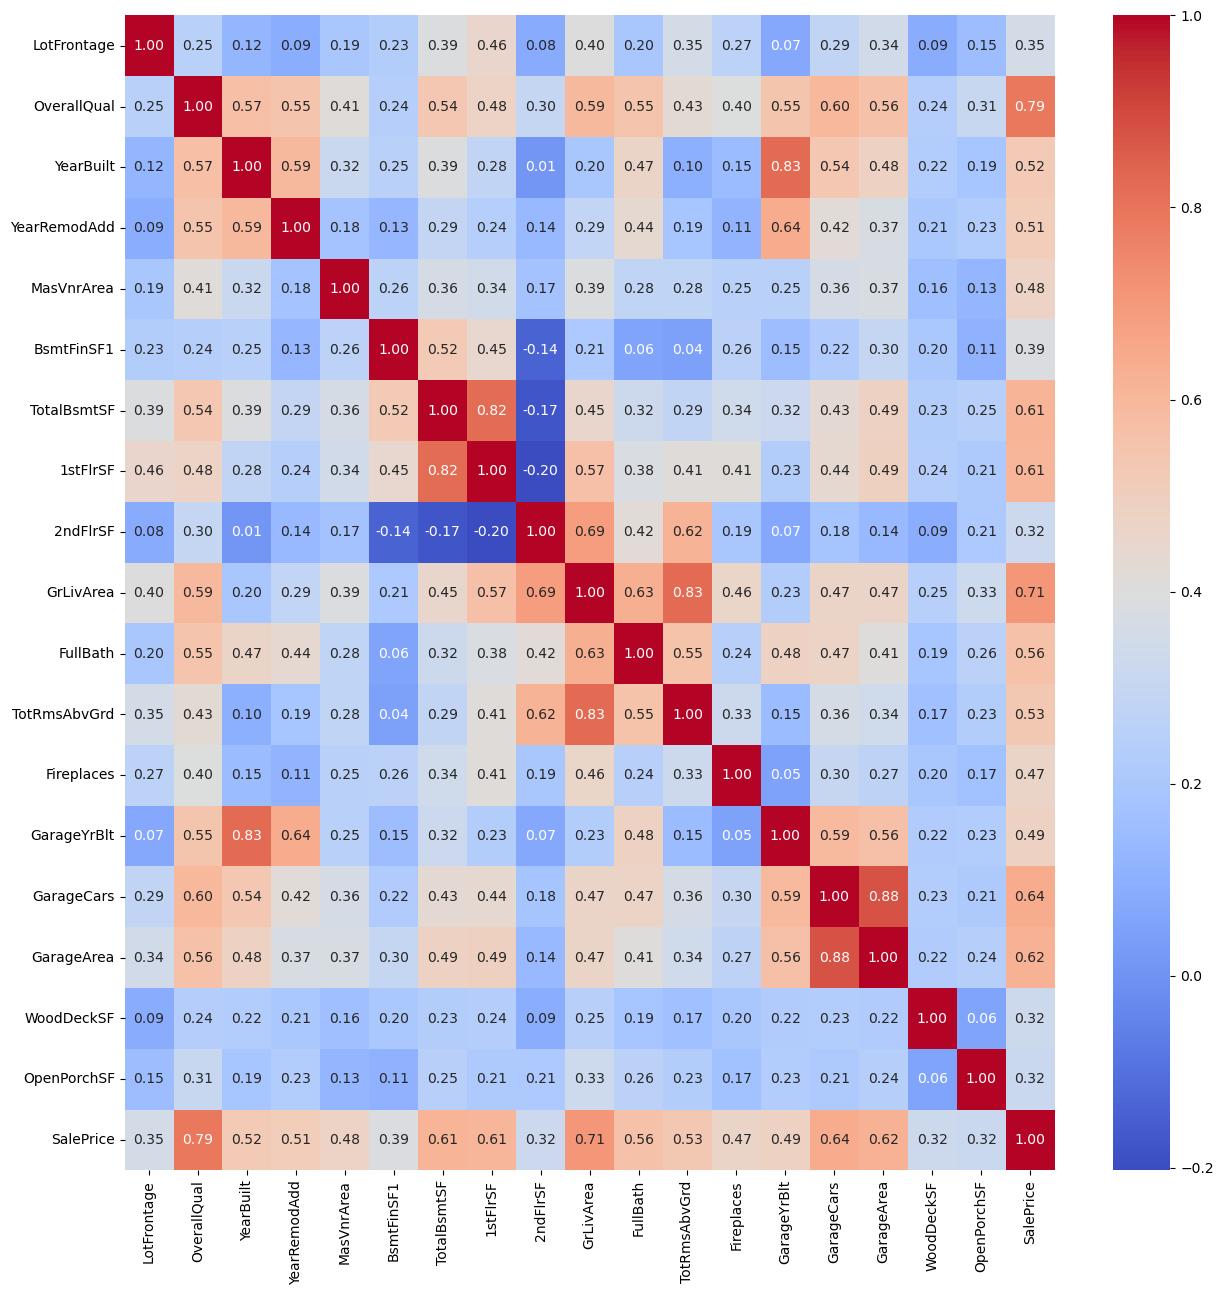

In [387]:
#make another heatmap with selected features only
plt.figure(figsize=(15,15))
correlation_matrix_selected = housing_price.corr()
sns.heatmap(correlation_matrix_selected, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":10})
plt.show()

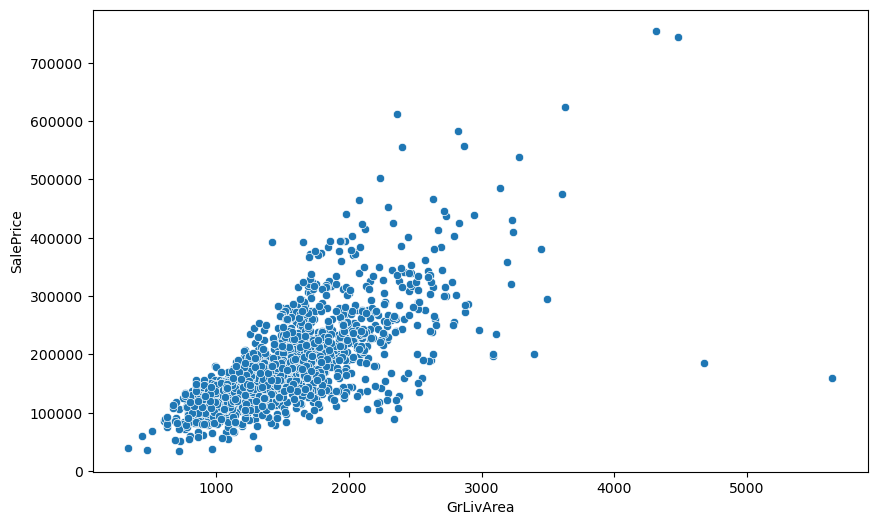

In [388]:
#look for outliers causing correlation issues
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing_price, x='GrLivArea', y='SalePrice')
plt.show()

#considering the graph below we can see as the living area increases the price should also increase. 
# However, there are two points with very high living area but low price which are likely outliers.

housing_price = housing_price.drop(housing_price[(housing_price['GrLivArea']>4000) & (housing_price['SalePrice']<300000)].index)

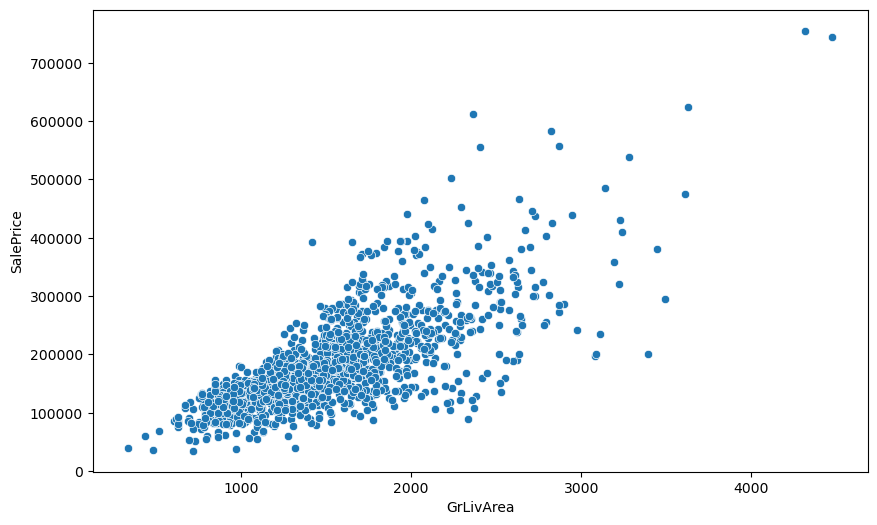

In [389]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing_price, x='GrLivArea', y='SalePrice')
plt.show()

In [390]:
#use describe again to see outliers in GrLivArea and SalePrice
housing_price[['GrLivArea', 'SalePrice']].describe()

#considering the output, most fall in the GrLivArea from a min of 334 to a max of 1776 which is the 75% quartile



,GrLivArea,SalePrice
count,1458.000000,1458.000000
mean,1510.465706,180932.919067
std,507.878508,79495.055285
min,334.000000,34900.000000
25%,1128.500000,129925.000000
50%,1461.500000,163000.000000
75%,1776.000000,214000.000000
max,4476.000000,755000.000000


In [391]:
#see how many are above 1776 + 526 for std dev GrlivArea and the SalePrice being higher than 214000 + 80000 for std dev


outliers = (housing_price['GrLivArea'] > 2302) | (housing_price['SalePrice'] > 294000)

print("number of outliers is :" + str(outliers.sum()))

print("out of total data set those 56 account for " + str((outliers.sum()/housing_price.shape[0])*100) + "% of the data")

number of outliers is :167
out of total data set those 56 account for 11.454046639231825% of the data


In [392]:
#lets drop those outliers
housing_price = housing_price.drop(housing_price[outliers].index)

In [393]:
#make sure we dropped anything above those values
housing_price[['GrLivArea', 'SalePrice']].describe()

,GrLivArea,SalePrice
count,1291.000000,1291.000000
mean,1396.111541,161527.255616
std,380.233610,50157.432468
min,334.000000,34900.000000
25%,1093.000000,127000.000000
50%,1383.000000,154500.000000
75%,1664.500000,192000.000000
max,2295.000000,294000.000000


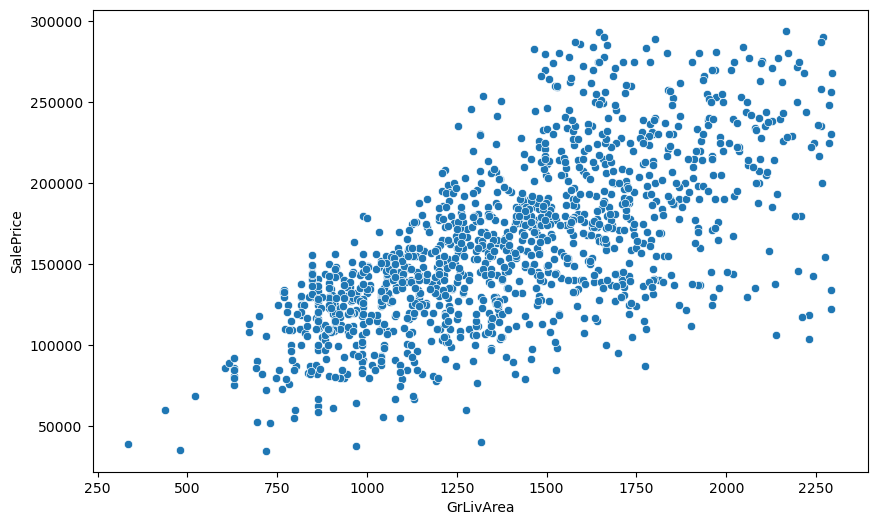

In [394]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing_price, x='GrLivArea', y='SalePrice')
plt.show()

#looks quite linear now without those outliers

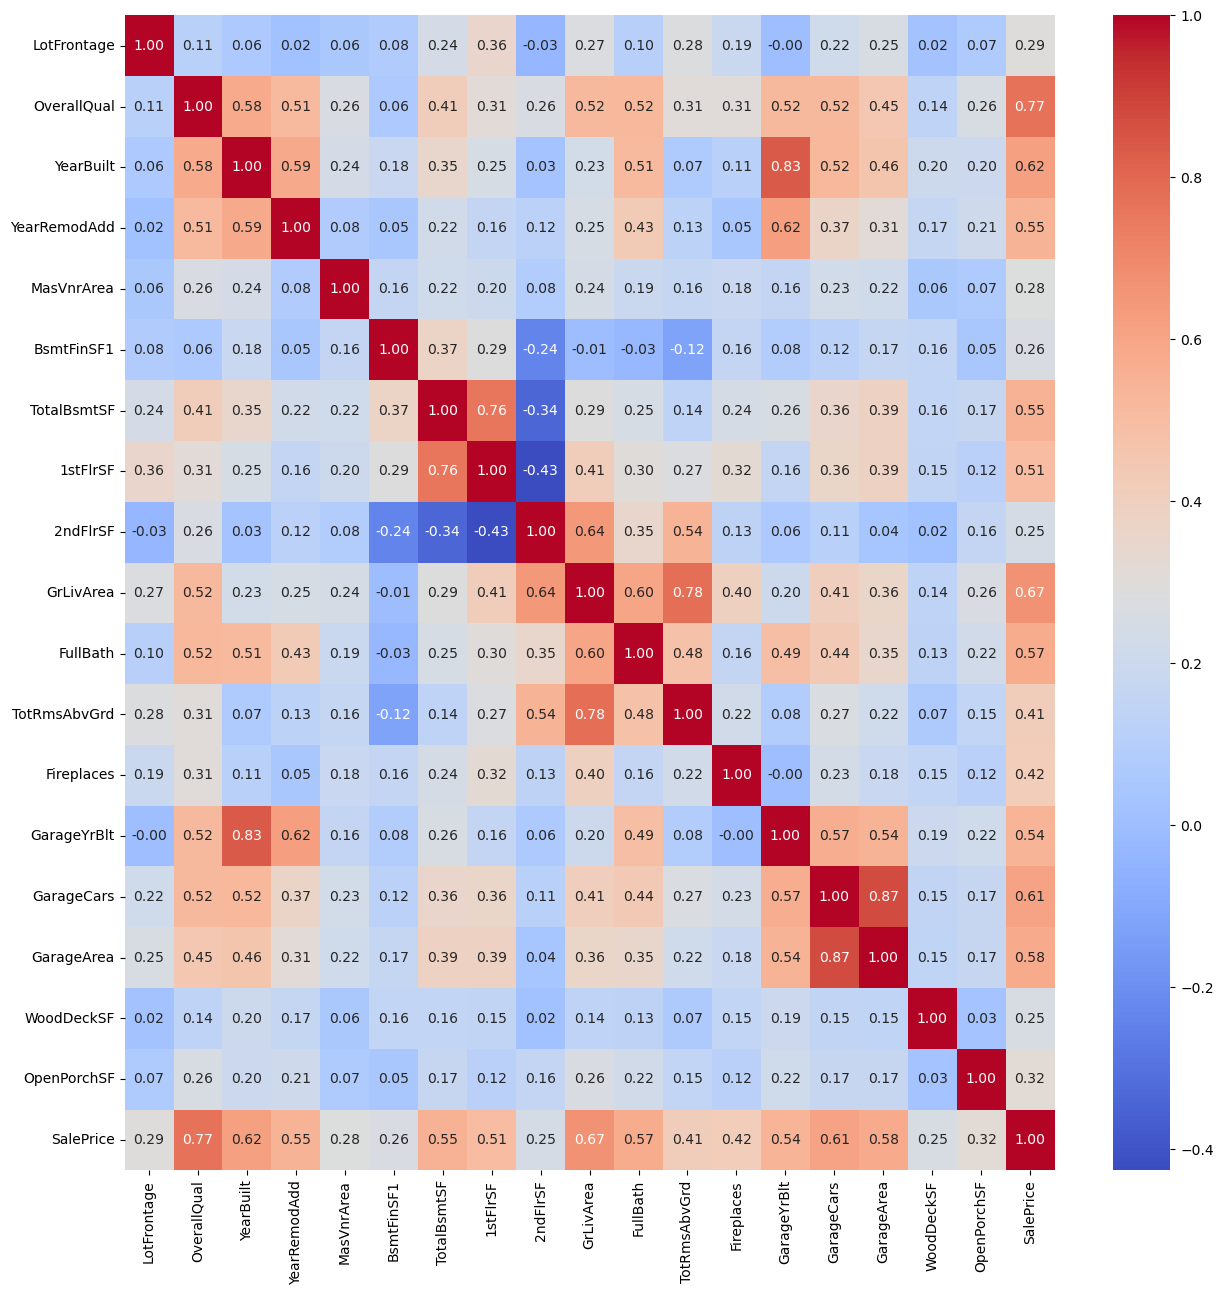

In [395]:
plt.figure(figsize=(15,15))
correlation_matrix_selected = housing_price.corr()
sns.heatmap(correlation_matrix_selected, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":10})
plt.show()

In [396]:
#check na's
housing_price.isna().sum().to_frame(name="missing_values")



,missing_values
LotFrontage,240
OverallQual,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,6
BsmtFinSF1,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
GrLivArea,0


In [397]:
#impute the lot frontage
housing_price["LotFrontage"] = housing_price["LotFrontage"].fillna(
    housing_price["LotFrontage"].mean()
)



In [398]:
#feature engineer total area, for GrLivArea, LotFrontage, WoodDeckSF, OpenPorchSF

housing_price["totalArea"] = (
    housing_price["GrLivArea"]
  + housing_price["LotFrontage"]
  + housing_price["WoodDeckSF"]
  + housing_price["OpenPorchSF"]
)

#considering the above heatmap it seems that these values don't matter anyways, lets drop those columns along wit the other irrelevant ones less than 0.3 and greater than -0.3
housing_price = housing_price.drop(columns=['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF'])

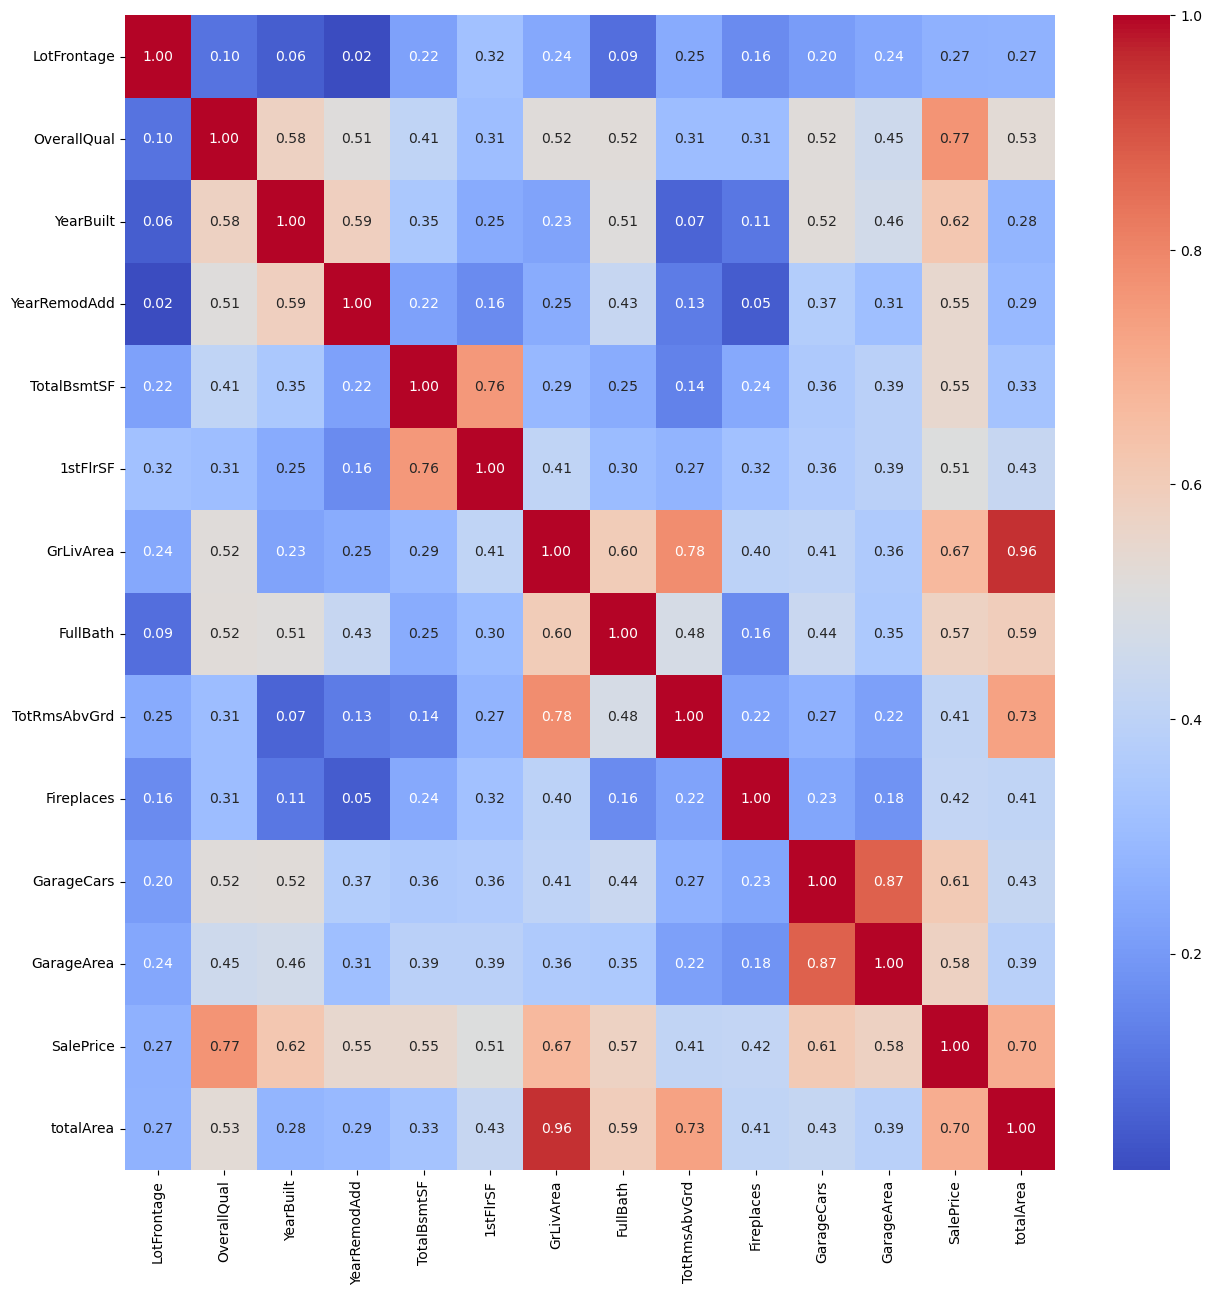

In [399]:
plt.figure(figsize=(15,15))
correlation_matrix_selected = housing_price.corr()
sns.heatmap(correlation_matrix_selected, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":10})
plt.show()

In [400]:
housing_price.columns

Index(['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'SalePrice', 'totalArea'],
      dtype='object')

In [401]:
#one bad assumption I made was we aren't taking into account people above a GrLivArea of 2302 and a salePrice of 294000


X = housing_price.drop(columns=['SalePrice'])
y = housing_price[['SalePrice']]


#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)

In [402]:
#make sure no na's 
housing_price.isna().sum()

LotFrontage     0
OverallQual     0
YearBuilt       0
YearRemodAdd    0
TotalBsmtSF     0
1stFlrSF        0
GrLivArea       0
FullBath        0
TotRmsAbvGrd    0
Fireplaces      0
GarageCars      0
GarageArea      0
SalePrice       0
totalArea       0
dtype: int64

In [403]:
#build and fit a linear model

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


y_train_pred = lin_reg.predict(X_train)
y_test_pred  = lin_reg.predict(X_test)


from sklearn.metrics import mean_squared_error
import numpy as np

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)


Train RMSE: 20385.726374600978
Test RMSE: 21633.026691537805


In [404]:
X_train.isna().sum().sort_values(ascending=False).head(10)
X_test.isna().sum().sort_values(ascending=False).head(10)


LotFrontage     0
OverallQual     0
YearBuilt       0
YearRemodAdd    0
TotalBsmtSF     0
1stFlrSF        0
GrLivArea       0
FullBath        0
TotRmsAbvGrd    0
Fireplaces      0
dtype: int64

In [405]:
from xgboost import XGBRegressor



xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [406]:
y_pred = xgb_model.predict(X_test)
#y_pred = np.expm1(y_pred)

rmsle = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSLE:", rmsle)




RMSLE: 20697.715202105115


In [407]:

#try including neighborhood from original train, we'll concat then one hot encode it
housing_price = pd.concat([housing_price, train['Neighborhood']], axis = 1)



In [408]:
from sklearn.preprocessing import OneHotEncoder

#make sure its there
housing_price.columns

#now one hot encode it
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
).set_output(transform="pandas")
neighborhood = train.copy()

#only have neighborhood
neighborhood = neighborhood[['Neighborhood']]

neighborhood_ohe = ohe.fit_transform(neighborhood[["Neighborhood"]])

#now only 

In [413]:
#make sure it has only neighborhood encoded cols
neighborhood_ohe.columns

#only neighborhood cols, so concat with current housing_price df

#housing_price = pd.concat([neighborhood_ohe, housing_price], axis = 1)

#drop neighborhood
housing_price = housing_price.drop(columns=['Neighborhood'])

housing_price.columns

Index(['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'SalePrice', 'totalArea'],
      dtype='object')

In [410]:
#betting it was when I dropped those outliers from before
housing_price.isna().sum()

housing_price = housing_price.dropna()

In [411]:
housing_price.columns

Index(['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'SalePrice', 'totalArea',
       'Neighborhood'],
      dtype='object')

In [414]:
#split
X = housing_price.drop(columns=['SalePrice'])
y = housing_price[['SalePrice']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=57)

#fit lasso on it

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

lasso = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 20580.48387337216


In [415]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, max_iter=50000, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

y_pred = lasso_pipe.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 20580.48406396788


In [419]:
coefs = lasso_pipe.named_steps["model"].coef_
coef_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coef": coefs
    })
)

coef_df.sort_values(by="coef", key=abs, ascending=False)


,feature,coef
1,OverallQual,14420.054621
12,totalArea,11914.432010
2,YearBuilt,7908.769825
4,TotalBsmtSF,6846.942782
6,GrLivArea,6789.645180
3,YearRemodAdd,6753.513004
11,GarageArea,6570.775742
9,Fireplaces,4825.072371
8,TotRmsAbvGrd,-3525.268299
0,LotFrontage,3401.651745


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        alphas=np.logspace(-4, 1, 50),
        cv=5,
        max_iter=50000,
        random_state=42
    ))
])

lasso_pipe.fit(X_train, y_train_log)

y_pred_log = lasso_pipe.predict(X_test)
rmsle = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print("Best alpha:", lasso_pipe.named_steps["model"].alpha_)
print("RMSLE:", rmsle)


In [420]:
from sklearn.feature_selection import f_regression

X = housing_price.drop(columns=["SalePrice"])
y = housing_price["SalePrice"]

f_vals, p_vals = f_regression(X, y)

f_df = (
    pd.DataFrame({
        "feature": X.columns,
        "F_stat": f_vals,
        "p_value": p_vals
    })
    .sort_values("F_stat", ascending=False)
)

f_df.head(15)


,feature,F_stat,p_value
1,OverallQual,1845.443859,5.547412e-251
12,totalArea,1264.753177,1.349476e-193
6,GrLivArea,1031.133326,1.017005e-166
2,YearBuilt,805.581901,4.617979e-138
10,GarageCars,762.912782,2.707704e-132
11,GarageArea,654.505097,4.435449e-117
7,FullBath,635.054695,2.928429e-114
4,TotalBsmtSF,557.440386,1.025495e-102
3,YearRemodAdd,552.632119,5.521794e-102
5,1stFlrSF,446.691515,2.282703e-85


In [ ]:

#how linear are these
housing_price.corr(method="pearson")["SalePrice"].sort_values(ascending=False)



SalePrice       1.000000
OverallQual     0.767309
totalArea       0.703742
GrLivArea       0.666655
YearBuilt       0.620163
GarageCars      0.609759
GarageArea      0.580315
FullBath        0.574509
TotalBsmtSF     0.549454
YearRemodAdd    0.547793
1stFlrSF        0.507303
Fireplaces      0.418522
TotRmsAbvGrd    0.412937
LotFrontage     0.266546
Name: SalePrice, dtype: float64

In [ ]:
#how much does each feature contribute linearly
housing_price.corr(method="spearman")["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
OverallQual     0.766122
totalArea       0.717786
GrLivArea       0.675424
YearBuilt       0.659838
GarageCars      0.633408
FullBath        0.609112
GarageArea      0.585826
YearRemodAdd    0.542843
TotalBsmtSF     0.518255
1stFlrSF        0.476554
Fireplaces      0.451893
TotRmsAbvGrd    0.447949
LotFrontage     0.300811
Name: SalePrice, dtype: float64